In [180]:
from langgraph.graph import StateGraph ,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator

In [181]:
load_dotenv()
model=ChatOpenAI(model='gpt-4o-mini')

In [182]:
class EveluateFeedback(BaseModel):
  feedback:str =Field(description='detailed feedback for the essay')
  score:int=Field(description='Score out of 10',gt=0,le=10 )

In [183]:
structured_model=model.with_structured_output(EveluateFeedback)

In [184]:
essay="""
# Artificial Intelligence: Transforming the Future

Artificial Intelligence (AI) is one of the most significant technological advancements of the modern era. It refers to the ability of machines and computer systems to perform tasks that typically require human intelligence, such as learning, reasoning, problem-solving, decision-making, and understanding language. Over the past few decades, AI has evolved from a theoretical concept into a practical technology that is transforming industries, economies, and everyday life.

One of the primary reasons for the rapid growth of AI is the availability of large amounts of data and powerful computing resources. Machine learning, a subset of AI, enables systems to learn patterns from data and improve their performance over time without being explicitly programmed. Deep learning, which uses neural networks inspired by the human brain, has further accelerated advancements in areas such as image recognition, natural language processing, and autonomous systems.

AI has made a significant impact across various sectors. In healthcare, AI-powered systems assist doctors in diagnosing diseases, analyzing medical images, and developing personalized treatment plans. These technologies help improve accuracy, reduce human error, and provide faster medical assistance. In finance, AI is used for fraud detection, risk assessment, algorithmic trading, and customer service through intelligent chatbots. Businesses leverage AI to analyze customer behavior, optimize operations, and improve decision-making processes.

The transportation industry has also benefited greatly from AI. Self-driving vehicles use AI algorithms to process information from sensors and cameras, enabling them to navigate roads and make real-time decisions. Although fully autonomous transportation is still under development, AI has already enhanced safety features and traffic management systems.

Education is another field experiencing transformation through AI. Intelligent tutoring systems provide personalized learning experiences by adapting content based on a student's strengths and weaknesses. AI-powered tools can automate administrative tasks, allowing educators to focus more on teaching and mentoring students.

Despite its numerous advantages, AI presents several challenges. One major concern is the potential impact on employment. As automation becomes more widespread, certain jobs may be replaced by machines, requiring workers to develop new skills and adapt to changing job markets. Privacy and security are also critical issues, as AI systems often rely on large volumes of personal data. Ensuring that this data is handled responsibly is essential for maintaining public trust.

Ethical considerations play a crucial role in AI development. Bias in training data can lead to unfair or discriminatory outcomes, affecting decisions related to hiring, lending, healthcare, and law enforcement. Therefore, researchers and organizations must focus on developing transparent, fair, and accountable AI systems. Governments and regulatory bodies are increasingly working to establish guidelines and policies that promote responsible AI usage.

The future of AI is filled with opportunities. Advances in generative AI, robotics, and intelligent agents are expected to create new possibilities in science, business, and everyday life. AI has the potential to accelerate research, improve productivity, and solve complex global challenges such as climate change, disease prevention, and resource management.

In conclusion, Artificial Intelligence is reshaping the world in profound ways. Its applications span across multiple industries, offering significant benefits in efficiency, innovation, and problem-solving. However, the successful adoption of AI requires careful attention to ethical, social, and economic challenges. By developing and using AI responsibly, society can harness its full potential to create a more advanced, productive, and sustainable future.

"""

In [185]:
essay1="""
# Artificial Intelligence and Its Impact on India

Artificial Intelligence (AI) is rapidly transforming the way nations develop, innovate, and compete in the global economy. India, with its large population, growing digital infrastructure, and strong technology sector, is uniquely positioned to benefit from the AI revolution. From healthcare and education to agriculture and governance, AI is creating new opportunities to address long-standing challenges and accelerate national development.

One of the most significant advantages India possesses is its vast pool of skilled engineers and software professionals. Over the years, the country has established itself as a global hub for information technology services. This strong technological foundation enables Indian companies, startups, and research institutions to adopt and develop AI solutions at a rapid pace. Government initiatives such as Digital India and IndiaAI further encourage innovation by supporting research, infrastructure, and talent development.

In the healthcare sector, AI is helping improve access to quality medical services. AI-powered diagnostic systems can analyze medical images, identify diseases at an early stage, and assist doctors in making informed decisions. This is particularly valuable in rural areas where access to specialist healthcare professionals is limited. AI-based telemedicine platforms are also bridging geographical barriers and enabling remote consultations for millions of citizens.

Agriculture, which employs a large portion of India's population, is another area where AI is making a significant impact. Farmers can use AI-driven tools to monitor crop health, predict weather patterns, optimize irrigation, and detect pest infestations. These technologies help increase productivity, reduce waste, and improve farmers' incomes. By combining AI with satellite imagery and sensor data, agricultural practices can become more efficient and sustainable.

The education sector is also benefiting from AI-powered solutions. Personalized learning platforms can adapt educational content according to a student's learning pace and abilities. Intelligent tutoring systems provide customized recommendations, helping students strengthen weak areas and improve overall performance. AI can also assist teachers by automating administrative tasks and generating insights about student progress.

India's financial sector has embraced AI for fraud detection, risk assessment, customer support, and personalized banking services. Banks and fintech companies use machine learning algorithms to identify suspicious transactions, improve credit scoring, and enhance customer experiences through virtual assistants and chatbots. These applications improve efficiency while reducing operational costs.

Despite its enormous potential, AI adoption in India faces several challenges. One major concern is the digital divide. While urban areas often enjoy high-speed internet and access to modern technology, many rural regions still lack adequate digital infrastructure. Bridging this gap is essential to ensure that the benefits of AI reach all sections of society. Another challenge is the shortage of advanced AI researchers and specialists. Continued investment in education, research, and skill development will be necessary to meet future demands.

Ethical considerations are equally important. AI systems can sometimes produce biased outcomes if trained on incomplete or unrepresentative data. Issues related to privacy, transparency, and accountability must be carefully addressed through appropriate regulations and responsible development practices. Policymakers, technology companies, and academic institutions must work together to establish ethical guidelines for AI deployment.

Looking ahead, AI has the potential to become a major driver of India's economic growth. It can enhance productivity across industries, create new employment opportunities, improve public services, and contribute to scientific innovation. Emerging technologies such as generative AI, autonomous systems, and intelligent agents are expected to further expand the scope of AI applications in the coming years.

In conclusion, Artificial Intelligence represents a transformative opportunity for India. By leveraging its technological talent, expanding digital infrastructure, and promoting responsible innovation, India can harness the power of AI to address critical challenges and improve the quality of life for its citizens. The successful integration of AI into various sectors will play a crucial role in shaping India's future as a global leader in technology and innovation.

"""

In [186]:
prompt=f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
structured_model.invoke(prompt)

EveluateFeedback(feedback='The essay presents a well-rounded discussion on the impact of Artificial Intelligence (AI) across various sectors, effectively highlighting both its benefits and challenges. The introduction is clear and sets the tone for the rest of the essay, engaging the reader with a broad overview of AI. The body paragraphs are well-organized, with each focusing on a specific sector where AI is making a significant impact, such as healthcare, finance, transportation, and education. This structured approach helps in maintaining coherence and clarity throughout the essay. Furthermore, the inclusion of ethical considerations and potential challenges adds depth to the discussion, demonstrating the complexity of AI\'s role in society.\n\nHowever, there are areas for improvement. The language is mostly formal and appropriate for an academic context, but at times it can be slightly verbose or repetitive (for example, the phrases "AI has made a significant impact across various 

In [187]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clearity_feedback: str
    overall_feedback: str

    individual_scores: Annotated[list[int], operator.add]

    avg_score: float

In [188]:
def eveluate_language(state:UPSCState) :
  prompt=f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}"
  output=structured_model.invoke(prompt)

  return {
    "language_feedback": output.feedback,
    "individual_scores": [output.score]
  }


In [189]:
def eveluate_analysis(state:UPSCState) :
   prompt=f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}"
   output=structured_model.invoke(prompt)
  
   return {'analysis_feedback':output.feedback,'individual_scores':[output.score]}

In [190]:
def eveluate_thought(state:UPSCState) :
    prompt=f"Evaluate the clearity of thouth of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}"
    output=structured_model.invoke(prompt)
  
    return {'clearity_feedback':output.feedback,'individual_scores':[output.score]}

In [191]:
def final_eveluation(state: UPSCState):

    prompt = f"""
    Based on the following feedback, create a summarized evaluation.

    Language Feedback:
    {state['language_feedback']}

    Analysis Feedback:
    {state['analysis_feedback']}

    Clarity Feedback:
    {state['clearity_feedback']}
    """

    overall_feedback = model.invoke(prompt).content

    avg_score = (
        sum(state['individual_scores'])
        / len(state['individual_scores'])
    )

    return {
        "overall_feedback": overall_feedback,
        "avg_score": round(avg_score, 2)
    }

In [192]:
graph=StateGraph(UPSCState)

graph.add_node('eveluate_language',eveluate_language)
graph.add_node('eveluate_analysis',eveluate_analysis)
graph.add_node('eveluate_thought',eveluate_thought)
graph.add_node('final_eveluation',final_eveluation)

#edge
graph.add_edge(START,"eveluate_language")
graph.add_edge(START,"eveluate_analysis")
graph.add_edge(START,"eveluate_thought")

graph.add_edge("eveluate_language",'final_eveluation')
graph.add_edge("eveluate_analysis",'final_eveluation')
graph.add_edge("eveluate_thought",'final_eveluation')

graph.add_edge('final_eveluation',END)

workflow=graph.compile()


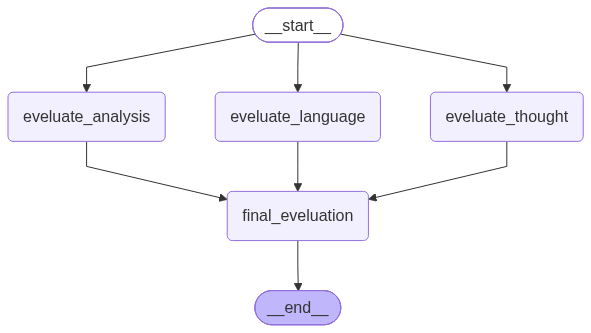

In [193]:
workflow

In [194]:
initial_state = {
    "essay": essay1
}

In [195]:
result = workflow.invoke(initial_state)

print(result["avg_score"])
print(result["overall_feedback"])

7.33
**Summary Evaluation:**

The essay provides a detailed examination of the impact of artificial intelligence (AI) across multiple sectors in India, including healthcare, agriculture, education, and finance. It effectively underscores the opportunities presented by AI alongside the challenges, such as the digital divide and ethical concerns. The structure is clear and logical, with well-defined sections that include relevant examples to bolster the discussion.

**Strengths:**

1. **Comprehensive Overview**: The essay successfully outlines AI’s potential benefits and challenges in India, demonstrating a clear understanding of the topic.
2. **Organized Structure**: Each paragraph is dedicated to specific areas of AI impact, supporting a coherent flow of ideas.
3. **Inclusion of Examples**: Relevant examples enhance the overall argument and illustrate AI's applications.

**Areas for Improvement:**

1. **Sentence Structure Variety**: Incorporating a wider range of sentence structures wo